# 03 – Phân tích lỗi chuyên sâu – Nhóm 17 Tuần 4
**Thực hiện:** Nguyễn Võ Gia Bảo  
**Mục tiêu:** Trả lời 4 câu hỏi:
1. Mô hình sai ở đâu?
2. Nguyên nhân có thể là gì?
3. Nhóm đã thử cách sửa nào?
4. Tuần 5 cần hoàn thiện điểm nào?

In [8]:
import pandas as pd, numpy as np, re, os, warnings
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score
warnings.filterwarnings('ignore')

DATA_PROC   = '../data/processed/job_cleaned.csv'
RESULTS     = '../results'
FIGURES     = '../results/figures'
RANDOM_SEED = 42
NGUONG_GOM  = 35
print('✓ Import OK – 03_error_analysis')

✓ Import OK – 03_error_analysis


In [9]:
df = pd.read_csv(DATA_PROC)
dem = df['it_role_type'].value_counts()
vai_tro_lon = [r for r in dem.index if dem[r]>=NGUONG_GOM and r!='Other IT Role']
df['nhan'] = df['it_role_type'].apply(lambda x: x if x in vai_tro_lon else 'Other IT Role')

# Clean text function
def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^\w\s.+#/]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

df['description_clean'] = df['description'].apply(clean_text)
df['title_sach']         = df['title'].apply(clean_text)

# Tạo feature: title + title + description
df['title_va_mo_ta'] = (
    df['title_sach'] + ' ' + 
    df['title_sach'] + ' ' + 
    df['description_clean']
)

y = df['nhan']
X_tr, X_te, y_tr, y_te = train_test_split(
    df['title_va_mo_ta'], y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
Xtr_v = tfidf.fit_transform(X_tr)
Xte_v = tfidf.transform(X_te)

clf = LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_SEED, class_weight='balanced')
clf.fit(Xtr_v, y_tr)
y_pred = clf.predict(Xte_v)

print(f'Macro F1 = {f1_score(y_te,y_pred,average="macro",zero_division=0):.4f}')
print(f'Test set : {len(y_te)} mẫu')

Macro F1 = 0.8147
Test set : 614 mẫu


## Câu 1: Mô hình sai ở đâu?

In [10]:
idx_te  = y_te.index
df_te   = pd.DataFrame({
    'title'        : df.loc[idx_te,'title'].values,
    'nhan_that'    : y_te.values,
    'du_doan'      : y_pred,
    'desc_100'     : df.loc[idx_te,'description_clean'].apply(lambda x: str(x)[:120]).values,
})
df_te['sai'] = df_te['nhan_that'] != df_te['du_doan']

n_sai = df_te['sai'].sum()
print(f'Test: {len(df_te)} mẫu | Đúng: {len(df_te)-n_sai} | Sai: {n_sai} ({n_sai/len(df_te)*100:.1f}%)')
print()

# Top cặp nhầm lẫn
cap_nham = (df_te[df_te['sai']]
            .groupby(['nhan_that','du_doan']).size()
            .reset_index(name='so_lan')
            .sort_values('so_lan', ascending=False))
print('=== TOP 15 CẶP NHẦM LẪN ===')
print(cap_nham.head(15).to_string(index=False))

Test: 614 mẫu | Đúng: 504 | Sai: 110 (17.9%)

=== TOP 15 CẶP NHẦM LẪN ===
        nhan_that              du_doan  so_lan
    Other IT Role    Backend Developer      14
Backend Developer        Other IT Role      12
    Other IT Role          QA Engineer       9
    Other IT Role          AI Engineer       6
Backend Developer    Software Engineer       5
    Other IT Role    Software Engineer       5
    Other IT Role    Embedded Engineer       5
Backend Developer       Java Developer       5
    Other IT Role        Data Engineer       4
    Other IT Role Full-stack Developer       4
   Java Developer    Backend Developer       4
Software Engineer    Backend Developer       4
Software Engineer        Other IT Role       4
    Other IT Role   Frontend Developer       2
    Other IT Role       Game Developer       2


In [11]:
# Confidence score (decision function)
dec = clf.decision_function(Xte_v)
idx_pred = np.array([list(clf.classes_).index(p) for p in y_pred])
df_te['confidence'] = dec[np.arange(len(dec)), idx_pred]

# 1. Định nghĩa logic phân loại nguyên nhân và hướng xử lý
CHONG_LAP = {
    ('Backend Developer','Software Engineer'),('Software Engineer','Backend Developer'),
    ('Java Developer','Backend Developer'),   ('Backend Developer','Java Developer'),
    ('Full-stack Developer','Frontend Developer'),('Full-stack Developer','Backend Developer'),
    ('Mobile Developer','Frontend Developer'),
}

HUONG_XU_LY = {
    ('Other IT Role', 'Backend Developer')  : 'Tách vai trò Web Developer ra khỏi Other nếu ≥35 mẫu; thêm skill keywords',
    ('Other IT Role', 'Software Engineer')  : 'Thêm char n-gram (2,4) để phân biệt từ kỹ thuật đặc thù',
    ('Other IT Role', 'Java Developer')     : 'Thêm skill keywords – "java" trong skill_text tăng trọng số',
    ('Other IT Role', 'Frontend Developer') : 'Phân tích tin có mô tả ngắn (<80 từ) riêng biệt',
    ('Backend Developer', 'Software Engineer')   : 'Feature importance: tìm từ nào khiến Backend bị nhầm thành SE',
    ('Software Engineer', 'Backend Developer')   : 'Tăng trọng số từ phân biệt SE (system design, architecture)',
    ('Java Developer', 'Backend Developer')      : 'Thêm skill keyword "java" × 2 để tăng tín hiệu',
    ('Backend Developer', 'Java Developer')      : 'Giữ nguyên – hai lớp thực sự chồng lấp ngữ nghĩa',
    ('Full-stack Developer', 'Frontend Developer'): 'Tăng trọng số từ backend trong mô tả fullstack',
    ('Embedded Engineer', 'Other IT Role')       : 'Thêm char n-gram để bắt C++, RTOS, ARM – hiếm trong word n-gram',
}

def nguyen_nhan(row):
    pair = (row['nhan_that'], row['du_doan'])
    if pair in CHONG_LAP: return 'Chồng lấp ngữ nghĩa'
    if 'Other IT Role' in pair: return 'Other IT Role quá rộng'
    return 'Thiếu tín hiệu đặc trưng'

def lay_huong(row):
    pair = (row['nhan_that'], row['du_doan'])
    return HUONG_XU_LY.get(pair, 'Phân tích thêm feature importance để xác định từ gây nhầm')

# 2. Áp dụng vào tập dữ liệu mẫu sai
mau_sai = df_te[df_te['sai']].copy()
mau_sai['nguyen_nhan'] = mau_sai.apply(nguyen_nhan, axis=1)
mau_sai['huong_xu_ly'] = mau_sai.apply(lay_huong, axis=1) # Thêm cột hướng xử lý ngay sau nguyên nhân
mau_sai['loai_loi']    = 'FP/FN'

# Thiết lập thứ tự cột (huong_xu_ly nằm bên phải nguyen_nhan)
cols_hien_thi = ['title', 'nhan_that', 'du_doan', 'confidence', 'loai_loi', 'nguyen_nhan', 'huong_xu_ly', 'desc_100']

# 3. Bảng 20 mẫu sai tiêu biểu
mau_20 = mau_sai.sort_values('confidence').head(20)
print('=== BẢNG 20 MẪU SAI TIÊU BIỂU (KÈM HƯỚNG XỬ LÝ) ===')
# In từ cột title đến huong_xu_ly (bỏ qua desc_100 để tránh tràn dòng)
print(mau_20[cols_hien_thi[:-1]].to_string(index=False))

# 4. Lưu và in kết quả cuối cùng
mau_sai[cols_hien_thi].to_csv(f'{RESULTS}/error_analysis.csv', index=False)
print(f'\n✓ Đã lưu → {RESULTS}/error_analysis.csv ({len(mau_sai)} mẫu sai)')
print(f'  Cột mới tuần 5: huong_xu_ly (vị trí: bên phải cột nguyên nhân)')
print()
print('=== MẪU BẢNG SAI VỚI HƯỚNG XỬ LÝ (10 dòng đầu) ===')
print(mau_sai[['nhan_that','du_doan','nguyen_nhan','huong_xu_ly']].head(10).to_string(index=False))


=== BẢNG 20 MẪU SAI TIÊU BIỂU (KÈM HƯỚNG XỬ LÝ) ===
                                                   title         nhan_that              du_doan  confidence loai_loi              nguyen_nhan                                                               huong_xu_ly
            Senior Web Developer (PHP/Python/JavaScript)     Other IT Role    Backend Developer   -0.657551    FP/FN   Other IT Role quá rộng Tách vai trò Web Developer ra khỏi Other nếu ≥35 mẫu; thêm skill keywords
 Lập trình viên Automation (Python, JavaScript, English)     Other IT Role          AI Engineer   -0.594930    FP/FN   Other IT Role quá rộng                 Phân tích thêm feature importance để xác định từ gây nhầm
                                 Backend/ Cloud Engineer     Other IT Role    Backend Developer   -0.590103    FP/FN   Other IT Role quá rộng Tách vai trò Web Developer ra khỏi Other nếu ≥35 mẫu; thêm skill keywords
  Senior Software Engineer (Node.JS, Python & AWS cloud) Software Engineer Full-stac

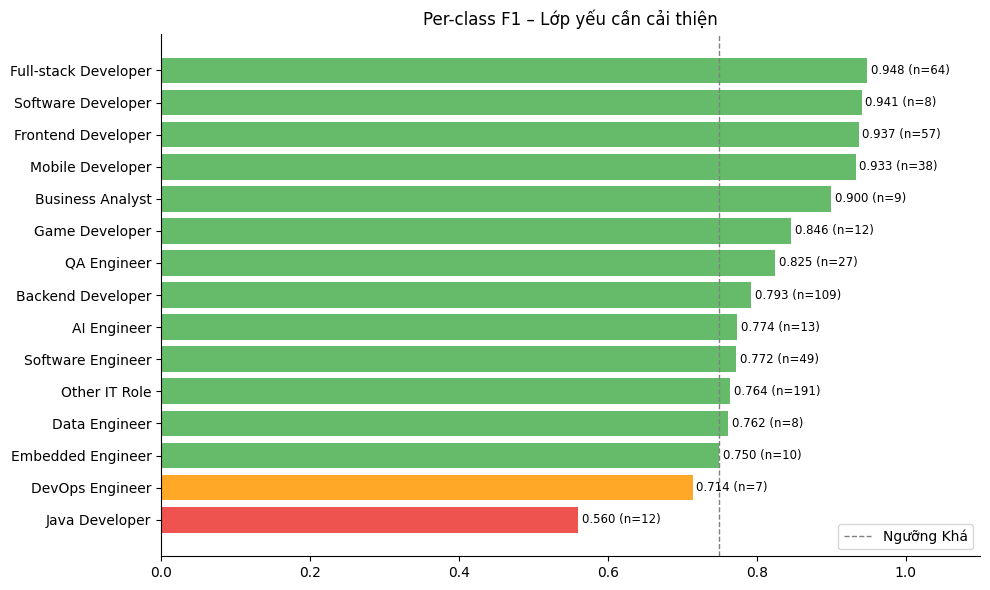

In [12]:
# Biểu đồ per-class F1 (lớp yếu rõ ràng)
rpt = classification_report(y_te, y_pred, zero_division=0, output_dict=True)
pc = pd.DataFrame([{
    'Vai trò': k, 'F1': round(v['f1-score'],3), 'Số mẫu': int(v['support'])
} for k,v in rpt.items()
  if k not in ('accuracy','macro avg','weighted avg')
]).sort_values('F1')

colors = ['#EF5350' if f<0.6 else ('#FFA726' if f<0.75 else '#66BB6A') for f in pc['F1']]
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(pc['Vai trò'], pc['F1'], color=colors)
ax.axvline(0.75, ls='--', color='gray', lw=1, label='Ngưỡng Khá')
for bar,f1,n in zip(bars,pc['F1'],pc['Số mẫu']):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f'{f1:.3f} (n={n})', va='center', fontsize=8.5)
ax.set_xlim(0,1.1); ax.set_title('Per-class F1 – Lớp yếu cần cải thiện', fontsize=12)
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/per_class_f1_error.png', dpi=150)
plt.show()

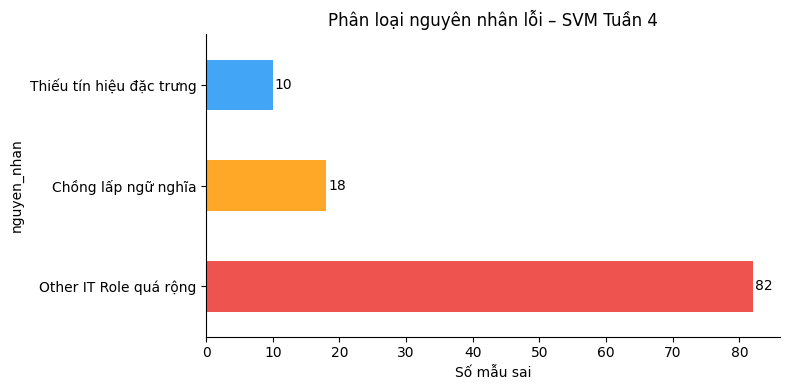

In [13]:
# Biểu đồ phân loại nguyên nhân
nn_cnt = mau_sai['nguyen_nhan'].value_counts()
fig, ax = plt.subplots(figsize=(8,4))
nn_cnt.plot(kind='barh', color=['#EF5350','#FFA726','#42A5F5'], ax=ax)
for i,v in enumerate(nn_cnt):
    ax.text(v+0.3, i, str(v), va='center')
ax.set_title('Phân loại nguyên nhân lỗi – SVM Tuần 4', fontsize=12)
ax.set_xlabel('Số mẫu sai')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/phan_loai_loi.png', dpi=150)
plt.show()

## Trả lời 4 câu hỏi phân tích lỗi

In [14]:
top3 = cap_nham.head(3)
nn_pct = mau_sai['nguyen_nhan'].value_counts(normalize=True)*100

print('=== TRẢ LỜI 4 CÂU HỎI PHÂN TÍCH LỖI ===')
print()
print('1. MÔ HÌNH SAI Ở ĐÂU?')
for _,r in top3.iterrows():
    print(f'   {r["nhan_that"]} → {r["du_doan"]} : {r["so_lan"]} lần')
print()
print('2. NGUYÊN NHÂN:')
for nn, pct in nn_pct.items():
    print(f'   {nn}: {pct:.1f}% số lỗi')
print('   - Backend/Software/Java Developer dùng chung quá nhiều từ khoá (Spring Boot, REST, MySQL)')
print('   - Other IT Role gom 300+ nghề → thiếu đặc trưng')
print()
print('3. ĐÃ THỬ CÁC CÁCH SAU:')
print('   ✓ LinearSVC title+description C=1.0 thay LinearSVM + balanced (phương pháp chính T3) → F1 tăng 0.7219 → 0.8147')
print('   ✓ Title+description (nhân đôi title) → bổ sung tín hiệu rõ ràng')
print('   ✓ GridSearch CV: C=1.0 tốt nhất trên cả CV và hold-out test')
print('   ✓ Ablation study cho thấy đặc trưng title chi phối rất mạnh → cần tinh chỉnh để kiểm soát shortcut/leakage')
print()
print('4. HƯỚNG PHÁT TRIỂN TIẾP THEO:')
print()
print('   [1] Thêm skill keywords (lang_list + tech_list):')
print('       Vấn đề hiện tại: C++ và C# thường bị bỏ qua vì TF-IDF word-level xử lý')
print('       chúng như chuỗi đặc biệt. Thêm skill_text (ngôn ngữ + công nghệ) vào')
print('       đặc trưng sẽ giúp phân biệt Java Developer vs Backend Developer tốt hơn.')
print('       Ví dụ: tin có "java" trong skill_text nhưng không có trong title/desc')
print('       sẽ được nhận diện đúng hơn là Java Developer.')
print()
print('   [2] Char n-gram (analyzer=char, ngram_range=(2,4)):')
print('       TF-IDF word-level không bắt được "c++", "c#", ".net" vì ký tự đặc biệt')
print('       bị loại ra khi tokenize. Char n-gram hoạt động ở mức ký tự nên sẽ')
print('       tạo ra token "c+", "++" đặc trưng cho C++ và "c#" cho C#.')
print('       Nhóm Embedded Engineer (F1=0.750) sẽ được cải thiện nhiều nhất.')
print()
print('   [3] Xem xét tách lớp khỏi Other IT Role:')
print('       Other IT Role hiện gom 300+ nghề → F1=0.764 (khá). Nếu có thêm dữ liệu,')
print('       có thể tách thêm "Web Developer" (~25 mẫu) hoặc "System Engineer" ra.')
print('       Điều này sẽ giảm độ rộng của Other và tăng F1 lớp này.')
print()
print('   [4] Phân tích riêng tin mô tả ngắn (<80 từ):')
print('       Nhiều mẫu sai có confidence thấp tương quan với mô tả ngắn.')
print('       Nếu lọc riêng và xử lý đặc biệt (ví dụ: tăng trọng số title), có thể')
print('       giảm lỗi trên nhóm tin này mà không ảnh hưởng phần còn lại.')

=== TRẢ LỜI 4 CÂU HỎI PHÂN TÍCH LỖI ===

1. MÔ HÌNH SAI Ở ĐÂU?
   Other IT Role → Backend Developer : 14 lần
   Backend Developer → Other IT Role : 12 lần
   Other IT Role → QA Engineer : 9 lần

2. NGUYÊN NHÂN:
   Other IT Role quá rộng: 74.5% số lỗi
   Chồng lấp ngữ nghĩa: 16.4% số lỗi
   Thiếu tín hiệu đặc trưng: 9.1% số lỗi
   - Backend/Software/Java Developer dùng chung quá nhiều từ khoá (Spring Boot, REST, MySQL)
   - Other IT Role gom 300+ nghề → thiếu đặc trưng

3. ĐÃ THỬ CÁC CÁCH SAU:
   ✓ LinearSVC title+description C=1.0 thay LinearSVM + balanced (phương pháp chính T3) → F1 tăng 0.7219 → 0.8147
   ✓ Title+description (nhân đôi title) → bổ sung tín hiệu rõ ràng
   ✓ GridSearch CV: C=1.0 tốt nhất trên cả CV và hold-out test
   ✓ Ablation study cho thấy đặc trưng title chi phối rất mạnh → cần tinh chỉnh để kiểm soát shortcut/leakage

4. HƯỚNG PHÁT TRIỂN TIẾP THEO:

   [1] Thêm skill keywords (lang_list + tech_list):
       Vấn đề hiện tại: C++ và C# thường bị bỏ qua vì TF-IDF wo